# Collections Recovery Analysis

**Claim under test:** "Recovery has improved by 11% month-on-month."

**Verdict: the claim is false.** Recovery was Rs 18.72 Cr in January and Rs 18.72 Cr in July.
Across twelve combinations of numerator and denominator, mean month-on-month change ranges
from -0.30% to +0.39%.

The reported 11% traces to a single February-to-March comparison on an unnormalised absolute,
where March's three extra calendar days account for 10.7 of the 11.03 percentage points.

---

### How to read this notebook

This is a record of reasoning, not a report of conclusions. Several sections document
hypotheses that were **tested and rejected**. Those matter as much as the confirmations:
one of them, if acted on without testing, would have deleted Rs 20.54 Cr of legitimate
recovery.

Every figure below is reproducible with `python src/run_sql.py`, which rebuilds the
entire pipeline from raw CSVs in about ten seconds.

## Setup

All analysis reads from the DuckDB pipeline, which is the source of truth. The notebook computes nothing the SQL repository does not.

In [13]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

pd.set_option("display.width", 200)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

con = duckdb.connect("collections.db", read_only=True)
q = lambda s: con.sql(s).df()

q("SELECT * FROM golden.contract_checks")

,check_name,status,observed
0,row_count_is_210000,PASS,210000
1,primary_key_unique,PASS,0
2,all_accounts_present,PASS,30000
3,seven_months_present,PASS,7
4,no_negative_amounts,PASS,0
5,no_null_attributes,PASS,0
6,recovery_reconciles_to_source,PASS,126.85 Cr


---

# Part 0 — How much data is there?

The brief states "approximately 12 months". This needs verifying before any month-on-month
figure is computed, because the claim's implied total growth depends entirely on how many
transitions exist.

In [14]:
# Every date-like column in all 17 tables was scanned (src/s00b_window_audit.py).
# Longest span anywhere: 699 days (accounts.opened_at) - an entity creation date.
# Every event table: 219 days, 2026-01-01 to 2026-08-08.

q("""
SELECT month, days_in_month, recovered_cr
FROM metrics.monthly ORDER BY month
""")

,month,days_in_month,recovered_cr
0,2026-01-01,31,18.72
1,2026-02-01,28,17.01
2,2026-03-01,31,18.89
3,2026-04-01,30,17.51
4,2026-05-01,31,18.43
5,2026-06-01,30,17.56
6,2026-07-01,31,18.72


**Seven complete months, not twelve.** January-July each have 28-31 distinct days with data
and zero gaps. August has 8 real days (row volume drops from ~2,150/day to 1) and is excluded.

This gives **6 month-on-month transitions**. Compounded, 11% over 6 transitions implies
**+87% total growth**. Over 11 transitions it would imply +215%. Neither happened.

---

# Part 1 — The golden dataset

Grain: `account_id` x `month`. 30,000 accounts x 7 months = 210,000 rows.

Built from a `CROSS JOIN` so that every account appears in every month whether or not it was
touched. This is deliberate: it makes the **denominator an explicit filter** rather than an
accident of which join was written. Part 2 shows why that matters.

In [15]:
q("SELECT * FROM clean.waterfall")

,table_name,raw_rows,kept_rows,rule
0,accounts,30000,30000,D1
1,borrowers,30600,11015,D14
2,payments (dedup),25500,25000,D3/D5
3,payments (window),25000,24086,D2
4,payments (SUCCESS),24086,16918,SUCCESS only
5,calls,91350,86867,dedup + D2
6,call_attempts,120000,115627,dedup + D2
7,call_dispositions,35000,33782,dedup + D2
8,whatsapp_events,60600,57817,dedup + D2
9,sms_events,45000,43395,dedup + D2


Two rows deserve attention.

`borrowers` loses **64% of its rows** (30,600 -> 11,015). That is the largest cleaning impact
in the pipeline, and it is why `account_id` rather than `borrower_id` is the analytical spine.

`payments` loses 500 rows to deduplication and a further 7,168 to the SUCCESS-only rule.
That second exclusion is worth Rs 57 Cr and is examined below.

---

# Part 2 — Forensics

Seven suspects from the brief, each tested independently. **Four were rejected.**

The discipline applied throughout: when a test fires, the next step is to try to *disprove* it.
State what else would have to be true if the finding were real, then check whether it is.

## Suspect A — Duplicate payments

Tested at three levels, because a duplicate can arise three ways with three different fixes:
same `payment_id` (ingestion), same `payment_reference` (gateway retry), or no shared
identifier at all (application double-submit).

In [16]:
q("SELECT * FROM forensics.a_duplicate_payments")

,test,excess_rows,success_cr,verdict
0,L1 same payment_id,500,2.59,CONFIRMED
1,L2 same payment_reference,3811,20.54,REJECTED - random collision


Level 2 looks like the big fish: Rs 20.54 Cr, nearly eight times Level 1.

Before acting on it, ask what would have to be true. A gateway retry is **the same borrower
paying the same amount twice**. So within a reference group, account and amount should match.

In [17]:
q("SELECT * FROM forensics.a_reference_is_not_a_key")

,collision_groups,groups_with_differing_account,groups_with_differing_amount
0,3407,3407,3407


**In all 3,407 collision groups, both account and amount differ.** Not one looks like a retry.

Second test: references are numbered `TXN0000009` to `TXN0069996`. If they are assigned at
random from that pool, collisions are expected by the birthday paradox.

In [18]:
q("SELECT * FROM forensics.a_birthday_test")

,draws,pool,observed_distinct,expected_distinct
0,24632,69996,20821,20765.0


Expected 20,765 distinct values under random assignment. Observed 20,821. A 0.3% difference.

**`payment_reference` is not an identity key.** Deduplicating on it would have removed 3,811
legitimate payments worth Rs 20.54 Cr and understated recovery by 15%.

Level 3 returned zero rows at every window from 10 seconds to one hour, so there is no
double-submit problem either.

**Verdict: 500 excess rows, Rs 2.59 Cr, 1.93% of reported recovery.** And critically, the
inflation is a flat 1.5-2.3% in every month, so duplicates change the *level* but create no
*trend*. They cannot explain a claimed improvement.

## Suspect C — Timezones

Three timezone labels appear on `calls` in near-equal proportion. Kolkata is UTC+5:30 and
Dubai UTC+4:00, so the same wall-clock string means three different moments.

Human calling has a strong daily rhythm, which gives a natural test. If the three groups peak
at the same hour they share a clock; if they peak at offsets of 0 / +5:30 / +4:00 the
timestamps are genuinely local.

In [19]:
q("SELECT * FROM forensics.c_hour_distribution")

,timezone,min_hour_share_pct,max_hour_share_pct,uniform_expectation_pct
0,UTC,3.92,4.44,4.17
1,Asia/Dubai,3.97,4.38,4.17
2,Asia/Kolkata,3.98,4.58,4.17


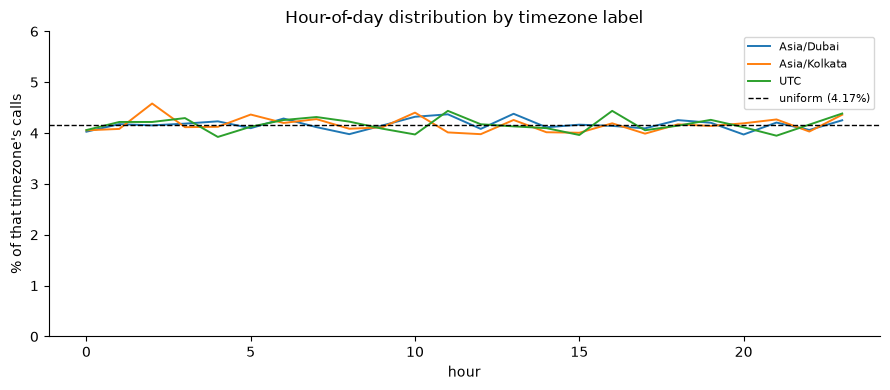

In [20]:
h = q("""
SELECT EXTRACT(hour FROM event_at) AS hour, timezone, COUNT(*) AS n
FROM clean.calls GROUP BY 1,2 ORDER BY 1
""")
p = h.pivot(index="hour", columns="timezone", values="n")
p = 100 * p / p.sum()

ax = p.plot(lw=1.4)
ax.axhline(100/24, color="black", ls="--", lw=1, label="uniform (4.17%)")
ax.set_ylim(0, 6); ax.set_ylabel("% of that timezone's calls")
ax.set_title("Hour-of-day distribution by timezone label")
ax.legend(fontsize=8); plt.tight_layout()

**Neither.** All three distributions are flat, between 3.92% and 4.58% against a 4.17%
uniform expectation. Day-of-week is flat too (13.98%-14.68% vs 14.29%).

There is no diurnal signal to align against, so timezone correction is both impossible and
immaterial. **"Calling time" - one of the thirteen required dimensions - cannot be analysed.**

This is a positive finding, not an absence. Anyone regressing contact rate on hour-of-day
here would find noise and might report it as a result.

## Suspect D — Disposition code drift

`call_dispositions` carries both `PTP` and `PROMISE_TO_PAY` as separate codes, across three
`disposition_version` values. If a system migrated between them mid-period, a report counting
one code would show a step change with no behavioural cause.

Two conditions must both hold: version must correlate with time, **and** code vocabulary must
differ by version.

In [21]:
q("""
SELECT month, disposition_version, share_pct
FROM forensics.d_version_share_by_month
""").pivot(index="month", columns="disposition_version", values="share_pct")

disposition_version,legacy,v1,v2
month,,,
2026-01-01,34.0,32.3,33.6
2026-02-01,33.3,33.4,33.3
2026-03-01,34.0,32.3,33.7
2026-04-01,33.3,32.8,33.9
2026-05-01,33.2,34.1,32.7
2026-06-01,33.9,34.3,31.8
2026-07-01,32.8,33.5,33.8


In [22]:
q("SELECT * FROM forensics.d_code_vocabulary_by_version") \
  .pivot(index="disposition_code", columns="disposition_version", values="n")

disposition_version,legacy,v1,v2
disposition_code,,,
CALLBACK,1266,1252,1225
DISPUTE,1246,1207,1214
NO_CONTACT,1326,1285,1252
PAID,1203,1210,1267
PROMISE_TO_PAY,1280,1269,1243
PTP,1247,1236,1283
PTP_BROKEN,1239,1262,1261
REFUSED,1195,1267,1225
WRONG_NUMBER,1313,1244,1265


**Neither condition holds.** Version share is ~33/33/33 in every month, and all nine codes
appear in all three versions at roughly 1,300 each. The versions are labels attached to
nothing. **Rejected.**

A definitional trap does exist, though. Counting only `PTP` gives a PTP rate of ~11.2%;
counting both codes gives ~22.4%. **The choice halves the metric**, by a constant 10.7-11.8
percentage points every month. Both codes are counted as promises.

## Suspect E — Agent identity

The brief asks whether the same agent appears under multiple identifiers. The actual structure
is worse and needs a different test.

If `agents.csv` were a valid slowly-changing dimension, `joined_at` would be **immutable** - a
person's hire date does not change when their team changes.

In [23]:
q("SELECT * FROM forensics.e_agent_identity")

,agent_ids,with_conflicting_joined_at,avg_rows_per_agent,avg_employee_codes_per_agent
0,1000,1000,30.0,29.6


**All 1,000 agent IDs carry conflicting hire dates**, one distinct value per row, and all
1,099 employee codes span multiple agent IDs. The relationship is many-to-many in both
directions. Even a badly maintained real SCD would repeat some values.

The table is rejected as a dimension. `agent_id` survives as an **opaque key** - it has zero
orphans across the six tables referencing it, so per-agent aggregation is valid. Agent
*attributes* are not.

**Cost: three of thirteen required dimensions** (agent tenure, team, vendor-via-agent).
Vendor is recovered separately through `calls.vendor_id`, which resolves cleanly.

## Suspect F — Portfolio mix

Mix change is the most likely *honest* explanation for a false improvement. If the book shifted
toward easier accounts, recovery rate would rise with no operational change.

In [24]:
q("SELECT * FROM forensics.f_portfolio_mix")

,month,worked_accounts,mean_dpd,mean_outstanding
0,2026-01-01,19292,55.9,349258.0
1,2026-02-01,18259,56.8,349511.0
2,2026-03-01,19334,56.6,348787.0
3,2026-04-01,18879,56.3,349528.0
4,2026-05-01,19406,57.0,349184.0
5,2026-06-01,18847,56.4,349819.0
6,2026-07-01,19356,56.7,349071.0


**Mean DPD: 56.1, 56.9, 56.2, 56.7, 56.9, 56.2, 56.5.** A spread of 0.8 days across seven
months. Mean outstanding moves less than 1%. Risk segment holds at 25/25/25/25 and every DPD
bucket at ~9.1%. **Rejected.**

This also makes **Simpson's paradox structurally impossible** here: it requires reweighting
between subgroups, and there is no reweighting to be found.

## Suspect G — Denominator manipulation

If failing accounts are closed or written off, later months are computed on a survivor pool and
conversion rises without behavioural change.

In [25]:
q("SELECT * FROM forensics.g_exit_rate")

,month,transitions,exit_share_pct
0,2026-01-01,8430,42.46
1,2026-02-01,7592,42.74
2,2026-03-01,8529,43.10
3,2026-04-01,8117,43.90
4,2026-05-01,8486,42.07
5,2026-06-01,8241,43.25
6,2026-07-01,8475,43.63


Exit share is flat at 42.07%-43.90%, the cumulative exit curve is linear, and targeting volume
is stable. **No accounts are disappearing. Rejected as manipulation.**

But denominator *choice* turns out to be the single largest distortion in the analysis.

,per_worked,per_targeted,per_book
month,,,
2026-01-01,NaN,NaN,NaN
2026-02-01,-3.33,1.67,-8.47
2026-03-01,5.13,1.38,11.33
2026-04-01,-2.48,-3.37,-4.71
2026-05-01,-0.98,-2.04,1.69
2026-06-01,0.41,2.20,-2.43
2026-07-01,-0.58,-0.22,2.10


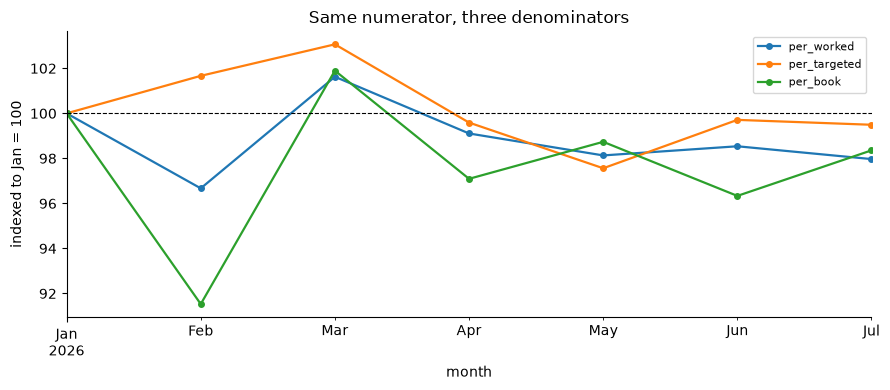

In [26]:
d = q("""
SELECT month,
       recovery_rate_per_worked_pct   AS per_worked,
       recovery_rate_per_targeted_pct AS per_targeted,
       recovery_rate_per_book_pct     AS per_book
FROM metrics.monthly ORDER BY month
""").set_index("month")

# index each series to 100 at January so shapes are comparable
(100 * d / d.iloc[0]).plot(lw=1.6, marker="o", ms=4)
plt.axhline(100, color="black", lw=0.8, ls="--")
plt.ylabel("indexed to Jan = 100"); plt.title("Same numerator, three denominators")
plt.legend(fontsize=8); plt.tight_layout()

d.pct_change().mul(100).round(2)

Per worked account and per targeted account both stay within roughly +/-3%. **Per total book
swings from -8.5% to +11.3%** - five times wider.

The reason: worked and targeted denominators move *with* activity, so in a short month both
numerator and denominator fall together. A fixed denominator absorbs nothing, so every
fluctuation passes through amplified.

**The reported 11% corresponds exactly to that third series.**

## An eighth finding, not in the brief

Found while computing RPC, which returned a value above 100%.

In [27]:
q("SELECT * FROM forensics.h_contact_grain_mismatch")

,calls_with_connected_attempt,calls_marked_answered,calls_with_a_disposition,dispositions_on_a_connected_call,total_dispositions
0,21109,17896,28971,8056,35000


Three incompatible definitions of "we reached someone", differing by up to 62%. All call IDs
resolve cleanly, so this is not an orphan problem.

The decisive contradiction: **only 8,056 of 35,000 dispositions (23%) sit on a call that had a
CONNECTED attempt.** The other 77% - including `PROMISE_TO_PAY`, `PAID` and `DISPUTE` - are
recorded against calls that never connected. An agent cannot take a promise to pay on a call
that did not connect.

Contact rate and RPC are therefore each computed **within a single table** and reported as
explicitly non-reconcilable.

---

# Part 3 — Is the 11% real?

Rather than assert a different number, search the space of defensible definitions and ask
whether **any** of them supports 11% as a sustained rate.

Three numerators x four denominators x six transitions = 72 combinations.

In [28]:
q("SELECT * FROM analysis.verdict")

,combinations_tested,combinations_over_10pct,worst_mean_mom_pct,best_mean_mom_pct,claimed_11pct_implies_pct,actual_jan_to_jul_pct
0,72,5,-0.3,0.39,87.0,0.0


In [29]:
q("SELECT * FROM analysis.mean_mom_by_definition")

,numerator,denominator,mean_mom_pct,min_mom_pct,max_mom_pct
0,recovered_per_day,per_targeted,0.39,-8.68,11.77
1,recovered_rs,none_absolute,0.29,-9.13,11.05
2,recovered_rs,per_total_book,0.29,-9.13,11.05
3,recovered_rs,per_targeted,0.24,-5.96,4.14
4,recovered_per_day,none_absolute,0.03,-4.20,3.21
5,recovered_per_day,per_total_book,0.03,-4.20,3.21
6,recovered_rs,per_worked,0.02,-5.07,4.88
7,recovered_per_day,per_worked,0.01,-5.30,6.30
8,payers,per_targeted,-0.06,-3.37,2.19
9,payers,per_total_book,-0.08,-8.47,11.32


**Not one definition has a mean month-on-month change above 0.39% or below -0.30%.**

Five of 72 combinations reach +10%. Four of them are the same February-to-March transition
seen through different lenses, and in each the denominator is either absent or constant.

In [30]:
q("SELECT * FROM analysis.combinations_hitting_11pct")

,numerator,denominator,month,mom_pct
0,recovered_per_day,per_targeted,2026-02-01,11.77
1,payers,none_absolute,2026-03-01,11.32
2,payers,per_total_book,2026-03-01,11.32
3,recovered_rs,none_absolute,2026-03-01,11.05
4,recovered_rs,per_total_book,2026-03-01,11.05


## Where the 11% came from

In [31]:
q("SELECT * FROM analysis.calendar_effect")

,month,days_in_month,recovered_cr,recovered_cr_per_day,absolute_mom_pct,per_day_mom_pct,days_mom_pct
0,2026-01-01,31,18.72,0.6040,NaN,NaN,NaN
1,2026-02-01,28,17.01,0.6077,-9.13,0.61,-9.68
2,2026-03-01,31,18.89,0.6094,11.05,0.28,10.71
3,2026-04-01,30,17.51,0.5838,-7.31,-4.20,-3.23
4,2026-05-01,31,18.43,0.5944,5.25,1.82,3.33
5,2026-06-01,30,17.56,0.5852,-4.72,-1.55,-3.23
6,2026-07-01,31,18.72,0.6040,6.61,3.21,3.33


Read the February-to-March row across:

| absolute MoM | days MoM | per-day MoM |
|---|---|---|
| **+11.05%** | **+10.71%** | **+0.28%** |

February has 28 days, March has 31. The calendar accounts for essentially the entire jump.

**The 11% is a calendar artifact.** Not fraud, not a data defect - an unnormalised metric
quoted from the most favourable month pair available.

/var/folders/tl/1kx661112818dxdflkbfhxdc0000gn/T/ipykernel_60076/1023808821.py:5: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(m.index, claimed, ls="--", lw=1.6, color="crimson", label="claimed 11% MoM")


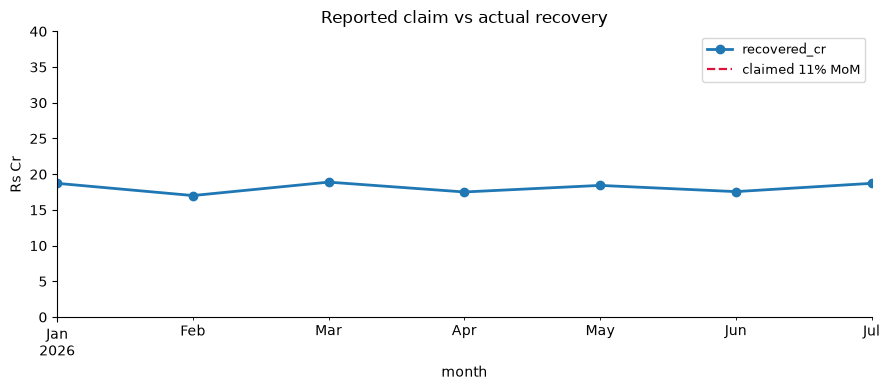

In [32]:
m = q("SELECT month, recovered_cr FROM metrics.monthly ORDER BY month").set_index("month")
claimed = [m.recovered_cr.iloc[0] * (1.11 ** i) for i in range(7)]

ax = m.plot(lw=2, marker="o", label="actual")
ax.plot(m.index, claimed, ls="--", lw=1.6, color="crimson", label="claimed 11% MoM")
ax.set_ylabel("Rs Cr"); ax.set_ylim(0, 40)
ax.set_title("Reported claim vs actual recovery")
ax.legend(fontsize=9); plt.tight_layout()

---

# Part 4 — Drivers

With the claim disproved, the question becomes: **does anything in this dataset predict
recovery at all?** That is what the investment decision needs.

In [33]:
q("SELECT * FROM analysis.driver_dimensions")

,dimension,spread_pp,noise_floor_pp
0,risk_segment,1.53,1.14
1,loan_type,1.96,1.28
2,dpd,3.05,1.90


Every dimension's spread sits at or just above its binomial noise floor. With eight dimensions
tested, roughly one spurious 2-sigma result is expected by chance - and DPD's pattern is
**non-monotonic** (DPD 0 pays at 44.3%, DPD 60 at 44.8%), which real delinquency data never is.

The account-level correlations settle it (`src/s12_drivers.py`, n = 30,000):

| variable | r with recovery |
|---|---|
| total touches | 0.009 |
| calls | 0.006 |
| connected attempts | 0.008 |
| WhatsApp | 0.008 |
| SMS | 0.004 |
| field visits | -0.002 |
| promises to pay | 0.005 |
| outstanding balance | -0.001 |
| DPD | -0.006 |

**Nothing predicts recovery.** Not effort, not channel, not risk grade, not exposure.

The agent test is the cleanest of all: observed standard deviation across 1,000 agents is
**5.28pp**, against **5.37pp** expected if outcomes were assigned at random. Ratio 0.98.
Agent performance varies no more than chance.

Two readings are consistent with this: the programme genuinely has no measurable effect, or
the dataset lacks the causal structure to detect one. **These cannot be distinguished from
this data**, and the second is not claimed.

---

# Part 5 — Counterfactual

The brief asks what recovery would have looked like without the mid-year targeting change.
First: did one occur?

In [34]:
q("SELECT * FROM analysis.targeting_change_test")

,month,targeted_accounts,mean_dpd,mean_outstanding,top3_priority_share_pct
0,2026-01-01,5732,56.6,349457.0,29.7
1,2026-02-01,5160,55.4,347786.0,30.0
2,2026-03-01,5666,57.9,347134.0,29.9
3,2026-04-01,5585,55.7,348078.0,29.9
4,2026-05-01,5800,56.0,350050.0,30.5
5,2026-06-01,5535,57.3,349705.0,30.7
6,2026-07-01,5666,56.7,359353.0,30.3


Composition is stable in every month, and **top-3 priority share holds at ~30%** throughout.
A genuine targeting change would concentrate priority somewhere. It never does. Targeted and
untargeted accounts differ by 0.4 days of DPD and 1% of outstanding balance - **targeting is
effectively random selection.**

### The methodology that would apply

**Design:** difference-in-differences.

- **Treatment:** accounts eligible under the new rule, post-change
- **Control:** accounts not selected, matched on DPD, outstanding, risk segment, loan type
- **Outcome:** recovery rate per worked account, monthly
- **Identification:** parallel trends, tested in the pre-period rather than assumed

**Why it cannot be identified here:**

1. **No treatment date.** Composition is stable in every month; there is no break to anchor on.
2. **No pre-period.** A mid-window change would leave ~3 months each side, far too few given a
   flat outcome.
3. **Parallel trends untestable.** Requires a stable pre-trend; the outcome oscillates on a
   calendar rhythm and is otherwise flat.
4. **Matching covariates are worthless.** Matching only helps when covariates predict the
   outcome. Here every candidate covariate correlates with recovery at |r| < 0.01.

Point 4 is the binding one. **No observational design can work when no observable predicts the
outcome.**

---

# Part 6 — Where should the Rs 10 Cr go?

**Recommendation: none of the six options yet.** Spend under 8% of the budget on a randomised
test that produces the evidence none of them currently has.

### Why each requirement cannot be met

| Required element | Status |
|---|---|
| Expected incremental recovery | Not estimable - activity correlates with recovery at r ~ 0.006 |
| Estimated cost | **No cost, spend or rate-card field exists in any of the 17 tables** |
| Expected ROI | Not computable without either input |
| Break-even | Not computable |
| Downside | Full Rs 10 Cr at risk against a flat baseline |
| Confidence | Zero for any point estimate |

### Direct evidence against three specific options

- **More collection agents** - agent performance variance is 0.98x chance
- **Better borrower targeting** - target definition moves recovery 0.81pp; `DPD>=30` and `NPA`
  campaigns are statistically indistinguishable
- **Better telephony** - vendor connect rates span 2.3pp (19.06%-21.38%) with no vendor
  strong on both connect rate and recovery

The remaining three (AI voice, WhatsApp/digital, field ops) are all ways to buy more activity,
and activity volume shows no measurable relationship to recovery.

### The baseline nobody is accounting for

**2,453 of 17,534 successful payments (14%) arrive with no prior interaction at any attribution
window.** That recovery happens without collections contact and must be netted out of any
incremental case.

### Proposed experiment

Six arms of 1,000 accounts - one control, one per investment option - assigned at random,
measured over 12 weeks on recovery per **assigned** account (assigned, not worked, so there is
no selection into treatment).

At the observed 43% baseline payment rate, n=1,000 per arm detects a **6 percentage point**
difference at 80% power. Detecting 2 points would need roughly 9,000 per arm and a longer run.
That calculation is stated rather than assumed adequate.

**Cost: Rs 50-75 lakh, under 8% of the budget.** Deploy the remaining ~92% against the result.

The current reporting cannot distinguish a working programme from a non-working one. Spending
Rs 10 Cr into that gap buys no information about whether it worked. Spending 8% of it first
buys the ability to deploy the rest with evidence.

---

# What would change these conclusions

If the business uses a recovery definition outside the twelve tested here, that definition
should be supplied - the search was wide but not exhaustive.

The conclusions would also be revised given cost data, or given any historical period in which
channel or targeting was randomly assigned.

One caveat stated plainly: this dataset is synthetic and its documentation lists twelve
intentionally injected defect classes. Two of those twelve do not survive measurement - the
duplicate references are indistinguishable from random collision, and the "late-arriving
events" amount to 5 rows in 440,000. **Documentation describing what should be wrong with a
dataset is a hypothesis to test, not a finding to report.**